In [ ]:
df = pd.read_csv("student_mental_health_burnout.csv")

In [ ]:
# Display the dataset shape
print("Dataset shape:")
print(df.shape)

Dataset shape:
(150000, 20)


In [ ]:
# Display the first five rows
print("First five rows:")
print(df.head())

First five rows:
   student_id  age  gender course year  daily_study_hours  daily_sleep_hours  \
0      100001   23    Male  BTech  1st                4.3                6.8   
1      100002   20    Male  BTech  3rd                1.4                4.7   
2      100003   24  Female    BCA  4th                3.7                4.8   
3      100004   21    Male    BSc  4th                1.6                6.7   
4      100005   23   Other    BSc  4th                2.0                6.7   

   screen_time_hours stress_level  anxiety_score  depression_score  \
0                6.1         High             10                 3   
1                3.0         High              2                10   
2                1.5          Low              2                 7   
3                7.0         High              3                 3   
4                5.4         High              7                 7   

   academic_pressure_score  financial_stress_score  social_support_score  \
0    

In [ ]:
# Check missing values
print("Missing values:")
print(df.isnull().sum())

Missing values:
student_id                 0
age                        0
gender                     0
course                     0
year                       0
daily_study_hours          0
daily_sleep_hours          0
screen_time_hours          0
stress_level               0
anxiety_score              0
depression_score           0
academic_pressure_score    0
financial_stress_score     0
social_support_score       0
physical_activity_hours    0
sleep_quality              0
attendance_percentage      0
cgpa                       0
internet_quality           0
burnout_level              0
dtype: int64


In [ ]:
# Check duplicate records
print("Duplicate records:")
print(df.duplicated().sum())

Duplicate records:
0


In [ ]:
# Create a copy of the dataset
df_cleaned = df.copy()

# Remove duplicate records
df_cleaned = df_cleaned.drop_duplicates()

# Display dataset shape after removing duplicates
print("Dataset shape after removing duplicates:")
print(df_cleaned.shape)

# Check duplicate records after cleaning
print("Duplicate records after cleaning:")
print(df_cleaned.duplicated().sum())

Dataset shape after removing duplicates:
(150000, 20)
Duplicate records after cleaning:
0


In [ ]:
# Identify numerical and categorical columns
numerical_cols = df_cleaned.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df_cleaned.select_dtypes(include=["object"]).columns.tolist()

# Remove student_id because it is only an identifier
if "student_id" in numerical_cols:
    numerical_cols.remove("student_id")

# Fill missing values in numerical columns using median
for col in numerical_cols:
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())

# Fill missing values in categorical columns using mode
for col in categorical_cols:
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mode()[0])

# Check missing values after cleaning
print("Missing values after cleaning:")
print(df_cleaned.isnull().sum())

print("Total missing values after cleaning:")
print(df_cleaned.isnull().sum().sum())

Missing values after cleaning:
student_id                 0
age                        0
gender                     0
course                     0
year                       0
daily_study_hours          0
daily_sleep_hours          0
screen_time_hours          0
stress_level               0
anxiety_score              0
depression_score           0
academic_pressure_score    0
financial_stress_score     0
social_support_score       0
physical_activity_hours    0
sleep_quality              0
attendance_percentage      0
cgpa                       0
internet_quality           0
burnout_level              0
dtype: int64
Total missing values after cleaning:
0


In [ ]:
# Handle outliers using IQR method
for col in numerical_cols:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_cleaned[col] = df_cleaned[col].clip(lower_bound, upper_bound)

print("Outlier handling completed using IQR method.")
print(df_cleaned[numerical_cols].describe())

Outlier handling completed using IQR method.
                 age  daily_study_hours  daily_sleep_hours  screen_time_hours  \
count  150000.000000      150000.000000      150000.000000      150000.000000   
mean       21.000380           5.507869           6.499361           6.502819   
std         2.581216           2.595592           1.443859           3.178948   
min        17.000000           1.000000           4.000000           1.000000   
25%        19.000000           3.300000           5.200000           3.700000   
50%        21.000000           5.500000           6.500000           6.500000   
75%        23.000000           7.700000           7.700000           9.300000   
max        25.000000          10.000000           9.000000          12.000000   

       anxiety_score  depression_score  academic_pressure_score  \
count  150000.000000     150000.000000            150000.000000   
mean        5.493907          5.497360                 5.507427   
std         2.872607    

In [ ]:
# Encode categorical wellbeing columns
stress_mapping = {"Low": 1, "Medium": 2, "High": 3}
sleep_quality_mapping = {"Poor": 1, "Average": 2, "Good": 3}
internet_quality_mapping = {"Poor": 1, "Average": 2, "Good": 3}
burnout_mapping = {"Low": 1, "Medium": 2, "High": 3}

df_cleaned["stress_level_encoded"] = df_cleaned["stress_level"].map(stress_mapping)
df_cleaned["sleep_quality_encoded"] = df_cleaned["sleep_quality"].map(sleep_quality_mapping)
df_cleaned["internet_quality_encoded"] = df_cleaned["internet_quality"].map(internet_quality_mapping)
df_cleaned["burnout_level_encoded"] = df_cleaned["burnout_level"].map(burnout_mapping)

print("Encoded categorical columns:")
print(df_cleaned[[
    "stress_level", "stress_level_encoded",
    "sleep_quality", "sleep_quality_encoded",
    "internet_quality", "internet_quality_encoded",
    "burnout_level", "burnout_level_encoded"
]].head())

Encoded categorical columns:
  stress_level  stress_level_encoded sleep_quality  sleep_quality_encoded  \
0         High                     3       Average                      2   
1         High                     3          Poor                      1   
2          Low                     1          Good                      3   
3         High                     3          Poor                      1   
4         High                     3          Good                      3   

  internet_quality  internet_quality_encoded burnout_level  \
0             Good                         3          High   
1             Poor                         1           Low   
2             Good                         3          High   
3             Good                         3          High   
4             Good                         3           Low   

   burnout_level_encoded  
0                      3  
1                      1  
2                      3  
3                      3  


In [ ]:
# Create wellbeing risk score
df_cleaned["wellbeing_risk_score"] = (
    df_cleaned["stress_level_encoded"] +
    df_cleaned["anxiety_score"] +
    df_cleaned["depression_score"] +
    df_cleaned["academic_pressure_score"] +
    df_cleaned["financial_stress_score"] +
    df_cleaned["burnout_level_encoded"] -
    df_cleaned["social_support_score"]
)

print("Wellbeing risk score created:")
print(df_cleaned[[
    "stress_level_encoded",
    "anxiety_score",
    "depression_score",
    "academic_pressure_score",
    "financial_stress_score",
    "burnout_level_encoded",
    "social_support_score",
    "wellbeing_risk_score"
]].head())

Wellbeing risk score created:
   stress_level_encoded  anxiety_score  depression_score  \
0                     3             10                 3   
1                     3              2                10   
2                     1              2                 7   
3                     3              3                 3   
4                     3              7                 7   

   academic_pressure_score  financial_stress_score  burnout_level_encoded  \
0                        4                       2                      3   
1                        8                       5                      1   
2                        8                       6                      3   
3                        4                       9                      3   
4                        6                       4                      1   

   social_support_score  wellbeing_risk_score  
0                     6                    19  
1                     9                    20  
2 

In [ ]:
# Create recommended resource based on student condition
def recommend_resource(row):
    if row["burnout_level"] == "High" or row["wellbeing_risk_score"] >= 25:
        return "Urgent Counselling Support"
    elif row["financial_stress_score"] >= 8:
        return "Financial Aid Guidance"
    elif row["academic_pressure_score"] >= 8:
        return "Academic Advisory and Study Support"
    elif row["social_support_score"] <= 3:
        return "Peer Support and Community Group"
    elif row["daily_sleep_hours"] < 6 or row["screen_time_hours"] > 7:
        return "Lifestyle and Sleep Guidance"
    else:
        return "General Wellbeing Resources"

df_cleaned["recommended_resource"] = df_cleaned.apply(recommend_resource, axis=1)

print("Recommended resource created:")
print(df_cleaned[[
    "wellbeing_risk_score",
    "burnout_level",
    "financial_stress_score",
    "academic_pressure_score",
    "social_support_score",
    "daily_sleep_hours",
    "screen_time_hours",
    "recommended_resource"
]].head())

Recommended resource created:
   wellbeing_risk_score burnout_level  financial_stress_score  \
0                    19          High                       2   
1                    20           Low                       5   
2                    24          High                       6   
3                    16          High                       9   
4                    24           Low                       4   

   academic_pressure_score  social_support_score  daily_sleep_hours  \
0                        4                     6                6.8   
1                        8                     9                4.7   
2                        8                     3                4.8   
3                        4                     9                6.7   
4                        6                     4                6.7   

   screen_time_hours                 recommended_resource  
0                6.1           Urgent Counselling Support  
1                3.0  Academic A

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Select columns for Min-Max Scaling
scale_cols = [
    "daily_study_hours",
    "daily_sleep_hours",
    "screen_time_hours",
    "anxiety_score",
    "depression_score",
    "academic_pressure_score",
    "financial_stress_score",
    "social_support_score",
    "physical_activity_hours",
    "attendance_percentage",
    "cgpa",
    "wellbeing_risk_score"
]

# Apply Min-Max Scaling
scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(df_cleaned[scale_cols])

# Create scaled DataFrame
scaled_df = pd.DataFrame(
    scaled_values,
    columns=[col + "_scaled" for col in scale_cols]
)

# Combine scaled columns with original cleaned dataset
df_cleaned = pd.concat([df_cleaned.reset_index(drop=True), scaled_df], axis=1)

print("Min-Max Scaling completed:")
print(df_cleaned[[col + "_scaled" for col in scale_cols]].head())

Min-Max Scaling completed:
   daily_study_hours_scaled  daily_sleep_hours_scaled  \
0                  0.366667                      0.56   
1                  0.044444                      0.14   
2                  0.300000                      0.16   
3                  0.066667                      0.54   
4                  0.111111                      0.54   

   screen_time_hours_scaled  anxiety_score_scaled  depression_score_scaled  \
0                  0.463636              1.000000                 0.222222   
1                  0.181818              0.111111                 1.000000   
2                  0.045455              0.111111                 0.666667   
3                  0.545455              0.222222                 0.222222   
4                  0.400000              0.666667                 0.666667   

   academic_pressure_score_scaled  financial_stress_score_scaled  \
0                        0.333333                       0.111111   
1                        

In [ ]:
# Aggregate wellbeing indicators by burnout level
burnout_summary = df_cleaned.groupby("burnout_level")[[
    "anxiety_score",
    "depression_score",
    "academic_pressure_score",
    "financial_stress_score",
    "social_support_score",
    "wellbeing_risk_score"
]].mean()

print("Aggregated summary by burnout level:")
print(burnout_summary)

Aggregated summary by burnout level:
               anxiety_score  depression_score  academic_pressure_score  \
burnout_level                                                             
High                5.486276          5.497287                 5.526002   
Low                 5.500428          5.490401                 5.500249   
Medium              5.494947          5.504433                 5.496148   

               financial_stress_score  social_support_score  \
burnout_level                                                 
High                         5.502150              5.513604   
Low                          5.494638              5.519347   
Medium                       5.491325              5.515199   

               wellbeing_risk_score  
burnout_level                        
High                      21.506370  
Low                       19.469492  
Medium                    20.473894  


In [ ]:
print("Final dataset shape:")
print(df_cleaned.shape)

print("Final dataset preview:")
print(df_cleaned.head())

print("Total missing values after pipeline:")
print(df_cleaned.isnull().sum().sum())

print("Total duplicate records after pipeline:")
print(df_cleaned.duplicated().sum())

Final dataset shape:
(150000, 38)
Final dataset preview:
   student_id  age  gender course year  daily_study_hours  daily_sleep_hours  \
0      100001   23    Male  BTech  1st                4.3                6.8   
1      100002   20    Male  BTech  3rd                1.4                4.7   
2      100003   24  Female    BCA  4th                3.7                4.8   
3      100004   21    Male    BSc  4th                1.6                6.7   
4      100005   23   Other    BSc  4th                2.0                6.7   

   screen_time_hours stress_level  anxiety_score  ...  \
0                6.1         High             10  ...   
1                3.0         High              2  ...   
2                1.5          Low              2  ...   
3                7.0         High              3  ...   
4                5.4         High              7  ...   

   screen_time_hours_scaled  anxiety_score_scaled  depression_score_scaled  \
0                  0.463636              

//Final Project

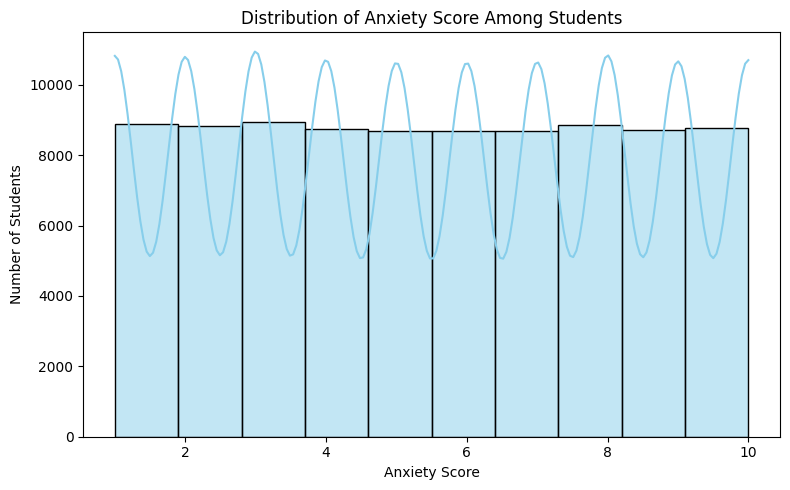

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("student_mental_health_burnout.csv")

plt.figure(figsize=(8, 5))
sns.histplot(df["anxiety_score"], bins=10, kde=True, color="skyblue")
plt.title("Distribution of Anxiety Score Among Students")
plt.xlabel("Anxiety Score")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()

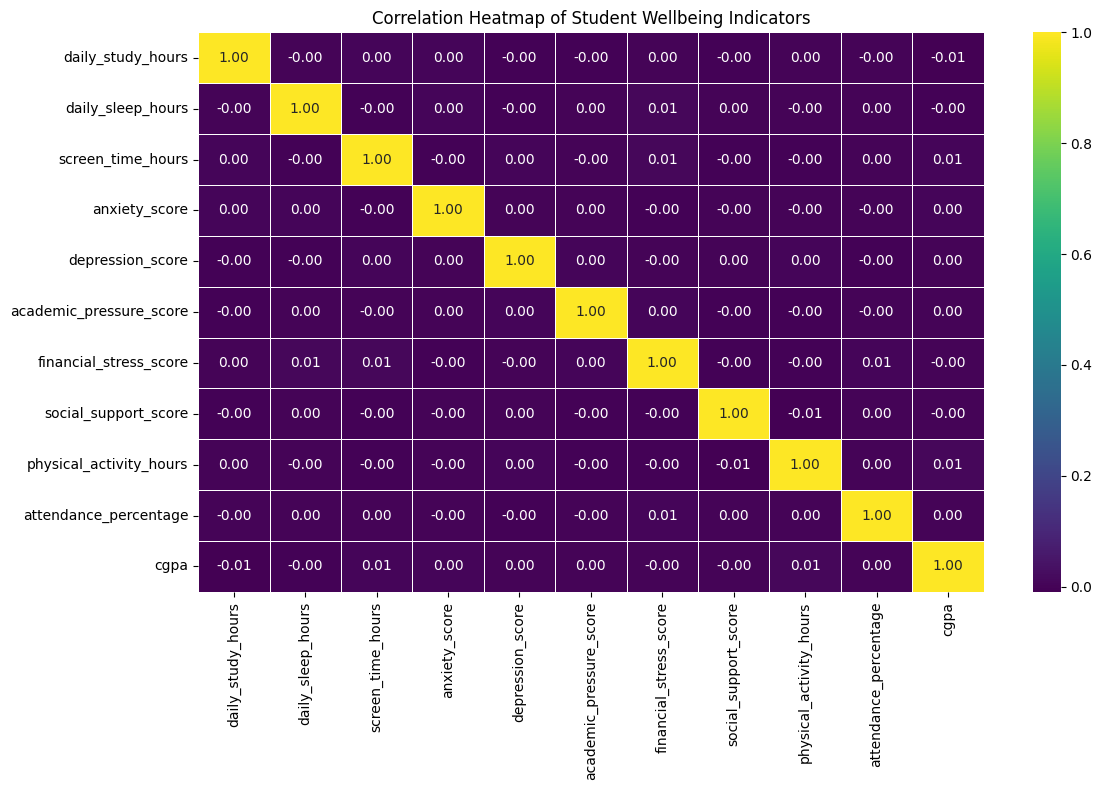

In [8]:
plt.figure(figsize=(12, 8))

numeric_cols = [
    "daily_study_hours",
    "daily_sleep_hours",
    "screen_time_hours",
    "anxiety_score",
    "depression_score",
    "academic_pressure_score",
    "financial_stress_score",
    "social_support_score",
    "physical_activity_hours",
    "attendance_percentage",
    "cgpa"
]

correlation_matrix = df[numeric_cols].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="viridis",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Student Wellbeing Indicators")
plt.tight_layout()
plt.show()

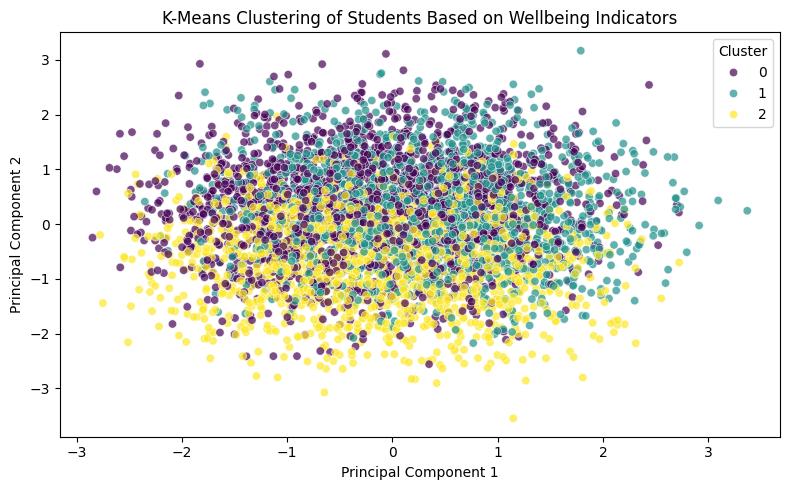

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Select wellbeing features for clustering
features = [
    "anxiety_score",
    "depression_score",
    "academic_pressure_score",
    "financial_stress_score",
    "social_support_score",
    "daily_sleep_hours",
    "screen_time_hours",
    "physical_activity_hours",
    "attendance_percentage",
    "cgpa"
]

X = df[features]

# Standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

# Reduce dimensions using PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

df["PCA1"] = pca_result[:, 0]
df["PCA2"] = pca_result[:, 1]

# Plot cluster result
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df.sample(5000, random_state=42),
    x="PCA1",
    y="PCA2",
    hue="cluster",
    palette="viridis",
    alpha=0.7
)

plt.title("K-Means Clustering of Students Based on Wellbeing Indicators")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

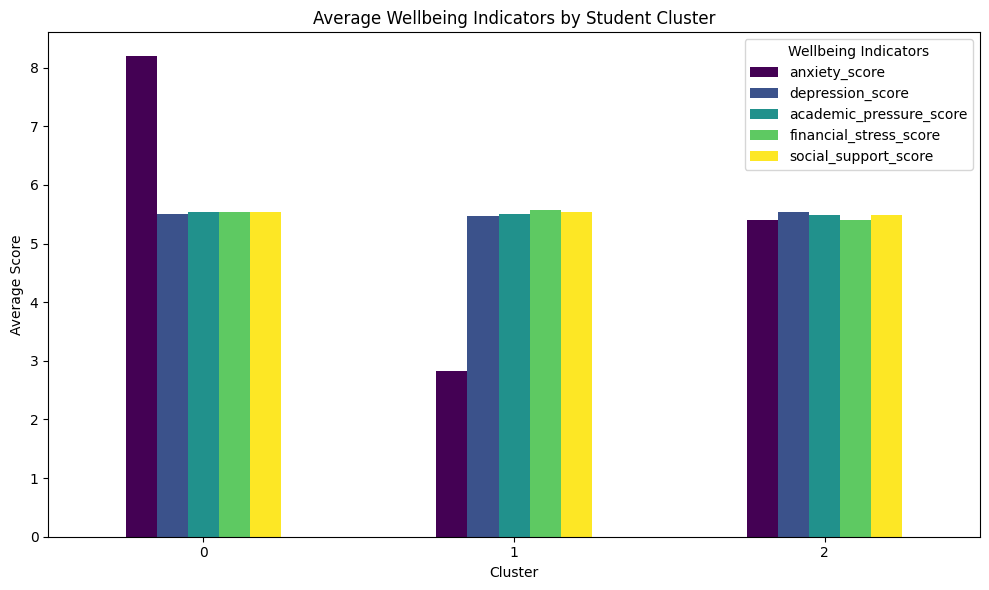

In [10]:
cluster_summary = df.groupby("cluster")[[
    "anxiety_score",
    "depression_score",
    "academic_pressure_score",
    "financial_stress_score",
    "social_support_score"
]].mean()

cluster_summary.plot(kind="bar", figsize=(10, 6), colormap="viridis")

plt.title("Average Wellbeing Indicators by Student Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.legend(title="Wellbeing Indicators")
plt.tight_layout()
plt.show()

In [5]:
def recommend_resource(row):
    if row["burnout_level"] == "High":
        return "Urgent Counselling Support"
    elif row["financial_stress_score"] >= 8:
        return "Financial Aid Guidance"
    elif row["academic_pressure_score"] >= 8:
        return "Academic Advisory and Study Support"
    elif row["social_support_score"] <= 3:
        return "Peer Support and Community Group"
    elif row["daily_sleep_hours"] < 6 or row["screen_time_hours"] > 7:
        return "Lifestyle and Sleep Guidance"
    else:
        return "General Wellbeing Resources"

df["recommended_resource"] = df.apply(recommend_resource, axis=1)

/tmp/ipykernel_19879/3405659702.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


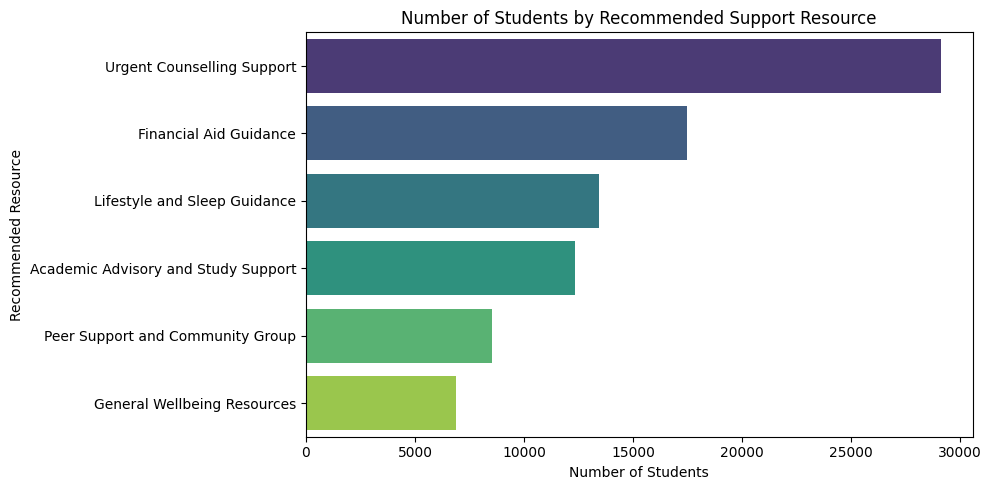

In [7]:
resource_count = df["recommended_resource"].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(
    x=resource_count.values,
    y=resource_count.index,
    palette="viridis"
)

plt.title("Number of Students by Recommended Support Resource")
plt.xlabel("Number of Students")
plt.ylabel("Recommended Resource")
plt.tight_layout()
plt.show()